# Basic elements and functions within this tutorial

<p style="line-height: 1.2;">
This Jupyternotebook serves to introduce key functions and variables in this tutorial. <br>
The sampler "ddpm_sampler" is skipped here. It will be demonstrated in the tutorial jupyternotebook <br>
</p>

In [39]:
# Import libraries
import torch 
import torch.nn as nn

from  torch.utils.data import DataLoader
from IPython.display import HTML
import numpy as np
import sys
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (4, 3)

In [40]:
sys.path.append('.')

In [41]:
# Import functions used here
from funs.SineWave_Dataset import SineWave_DataSet
from funs.scheduler import noise_scheduler, add_noise_onestep_cum_sampler
from funs.unet_1d import ConditionalUNet1D
from funs.time_embedding import get_sinusoidal_table


## Dataset 
### Generation
<p style="line-height: 1.2;">
Generation
The dataset used here is randomly generated sine waves. To initiate the dataset, we specify the max_frequency (freq_max).  <br>
For every sample, it first generates a random number in between 0 to freq_max, and then generates the sine wave from 0 - 2 * pi with 200 points following the generated frequency. <br>

### Content per sample
[0]: the generated frequency. <br>
[1]: the sine wave data (shape: 200). 
</p>

In [42]:
ds = SineWave_DataSet(freq_max = 5)
sample = ds[0]
sample_freq = sample[0]
sample_freq

tensor([2.0331])

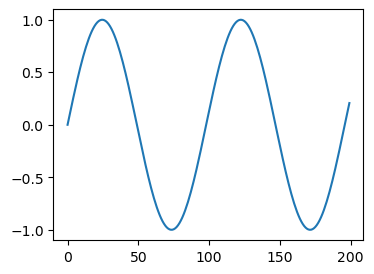

In [43]:
data = sample[1]
plt.plot(data)

### Linear Noise Scheduler

<p style="line-height: 1.2;">
This function constructs a linear noise schedule for the diffusion model. <br>
It generates a series of variables which are listed below. <br>
They all share the same dimesnion, which is the number of time steps used in diffusion model. <br>
They define how the noise is added during the destruction process, which also connects them to the reversed sampling procedure. <br>
</p>


In [44]:
schedules = noise_scheduler(beta_min = 1e-4, beta_max = 0.02, T = 500)

Adopting a linear scheduler


In [45]:
schedules.keys()

dict_keys(['betas', 'alphas', 'alpha_hats', 'alpha_hats_sqrt', 'one_minus_alpha_hats_sqrt', 'posterior_variance'])

In [46]:
schedules['betas'].shape, schedules['alphas'].shape, schedules['alpha_hats'].shape, schedules['alpha_hats_sqrt'].shape, schedules['one_minus_alpha_hats_sqrt'].shape, schedules['posterior_variance'].shape

(torch.Size([500]),
 torch.Size([500]),
 torch.Size([500]),
 torch.Size([500]),
 torch.Size([500]),
 torch.Size([500]))

## Destroy the sample
<p style="line-height: 1.2;">
Now let's see how one sample "data" is destroyed gradually with time <br>
Since the random noise is added to each dataset. At each time step, the sample can be destroyed in different ways<br>
Because of this, for each time step, three examples are shown with the same sample. <br>
As t becomes greater, the signal looks more like white noise. <br>
</p>


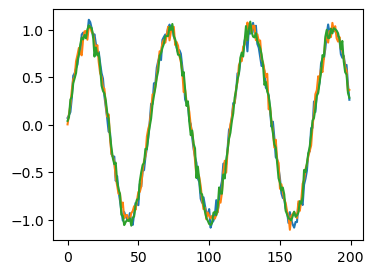

In [35]:
plt.plot(add_noise_onestep_cum_sampler(data, t = 10, scheduler_dict = schedules, no_samples = 1)); 
plt.plot(add_noise_onestep_cum_sampler(data, t = 10, scheduler_dict = schedules, no_samples = 1)); 
plt.plot(add_noise_onestep_cum_sampler(data, t = 10, scheduler_dict = schedules, no_samples = 1))

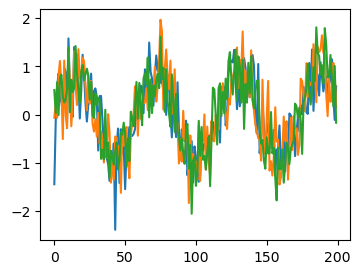

In [36]:
plt.plot(add_noise_onestep_cum_sampler(data, t = 100, scheduler_dict = schedules, no_samples = 1)); 
plt.plot(add_noise_onestep_cum_sampler(data, t = 100, scheduler_dict = schedules, no_samples = 1)); 
plt.plot(add_noise_onestep_cum_sampler(data, t = 100, scheduler_dict = schedules, no_samples = 1))

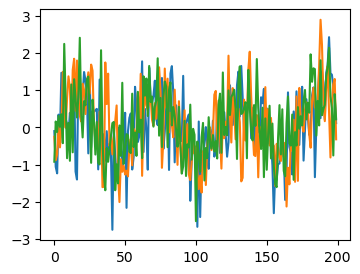

In [37]:
plt.plot(add_noise_onestep_cum_sampler(data, t = 200, scheduler_dict = schedules, no_samples = 1)); 
plt.plot(add_noise_onestep_cum_sampler(data, t = 200, scheduler_dict = schedules, no_samples = 1)); 
plt.plot(add_noise_onestep_cum_sampler(data, t = 200, scheduler_dict = schedules, no_samples = 1))

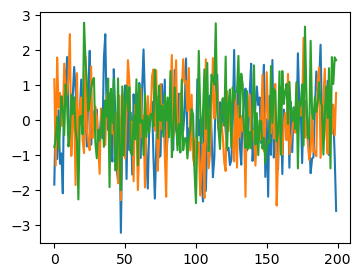

In [34]:
plt.plot(add_noise_onestep_cum_sampler(data, t = 400, scheduler_dict = schedules, no_samples = 1)); 
plt.plot(add_noise_onestep_cum_sampler(data, t = 400, scheduler_dict = schedules, no_samples = 1)); 
plt.plot(add_noise_onestep_cum_sampler(data, t = 400, scheduler_dict = schedules, no_samples = 1))

## Forward model

<p style="line-height: 1.2;">
We use a simple 1-D Unet as the forward model. <br>
Note that the model takes three inputs: <br>
</p>

<ul style="margin-left: 30px; line-height: 1.2;">
  <li><code>x_t_dummy:      The noisy x at time t </code></li>
  <li><code>t_dummy:        The time step </code></li>
  <li><code>The 3rd input:  None for this jupyternotebook It is designed for the conditional diffusion model that will be introduced in the future </code></li>
</ul>

In [13]:
unconditional_model = ConditionalUNet1D(in_channels= 1, base_channels= 64, t_steps= 500, t_dim= 64, cond_dim= 1, emb_dim= 72)
x_t_dummy = torch.randn(12, 1, 200)
t_dummy = torch.randint(1, 499, (12,))
x_cond = torch.randn(12, 1)
unconditional_model(x_t_dummy, t_dummy, None).shape

torch.Size([12, 1, 200])

## Time embedding

<p style="line-height: 1.2;">
When the diffusion model is used, the neural network needs to know the time step and uses it as one input <br>
A simple time index per sample is not enough, because that scalar is very weak and will likely be omitted during the backpropagation. <br>
Instead, we need a more comprehensive way to denote time. <br>
This is similar to using year, month, day, hour, and etc to denote time instead of just one value (say second) <br>
In this case, we project time into 64 dimensions. For each dimension, it is a sin/cos wave with different frequences. <br>
It can be considered as the cycles of year, month, day, hour, and etc such that the time can be ``better understood'' by the neural network <br>
</p>

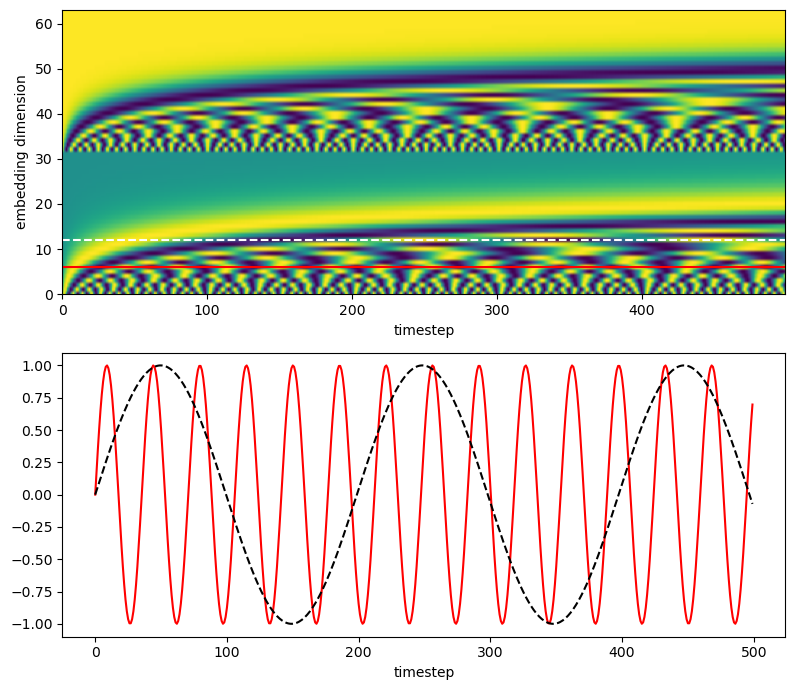

In [14]:
time_embedding_table = get_sinusoidal_table(500, 64)
fig, ax = plt.subplots(2, 1, figsize=(8, 7))  # (width, height) in inches

im = ax[0].imshow(time_embedding_table.T,aspect="auto",origin="lower",cmap="viridis")
ax[0].axhline(y = [6], color = "red")
ax[0].axhline(y = [12], color = "white", linestyle = '--')


ax[0].set_xlabel("timestep")
ax[0].set_ylabel("embedding dimension")
ax[0].set_xlim(0, time_embedding_table.shape[0] - 1)     # x-axis is timestep index
ax[0].set_ylim(0, time_embedding_table.shape[1] - 1)     # y-axis is embedding dim index

ax[1].plot(time_embedding_table[:,6], color = 'red')
ax[1].plot(time_embedding_table[:,12],color = 'black', linestyle = '--')
ax[1].set_xlabel("timestep")

plt.tight_layout()

plt.show()